In [1]:
# Cell 1: Setup
import sys
import pandas as pd
import numpy as np
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR
from src.data_loader import load_all_ethiopia_dhs
from src.data_cleaner import clean_all_years, select_final_columns
from src.wealth_proxy import create_consistent_wealth_for_all_years

print("Setup complete")
print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Processed data directory: {PROCESSED_DATA_DIR}")

Setup complete
Raw data directory: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\data\raw
Processed data directory: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\data\processed


In [2]:
# Cell 2: Load all DHS files
all_data = load_all_ethiopia_dhs(RAW_DATA_DIR)

for year, data_dict in all_data.items():
    df = data_dict['df']
    print(f"{year}: {len(df):,} rows, {len(df.columns):,} columns")

2026-04-04 23:56:09,861 - INFO - Loading ETIR41FL.DTA...
2026-04-04 23:56:21,423 - INFO - Successfully loaded 15,367 rows and 3665 columns
2026-04-04 23:56:21,429 - INFO - Loading ETIR51FL.DTA...
2026-04-04 23:56:37,411 - INFO - Successfully loaded 14,070 rows and 4699 columns
2026-04-04 23:56:37,416 - INFO - Loading ETIR61FL.DTA...
2026-04-04 23:56:49,857 - INFO - Successfully loaded 16,515 rows and 3807 columns
2026-04-04 23:56:49,857 - INFO - Loading ETIR71FL.DTA...
2026-04-04 23:57:08,923 - INFO - Successfully loaded 15,683 rows and 5902 columns


2000: 15,367 rows, 3,665 columns
2005: 14,070 rows, 4,699 columns
2011: 16,515 rows, 3,807 columns
2016: 15,683 rows, 5,902 columns


In [3]:
# Cell 3: Clean all years
cleaned_data = clean_all_years(all_data)

# Check results for 2000
print("\n2000 cleaned data sample:")
print(cleaned_data[2000][['survey_year', 'ever_married', 'age_first_marriage', 'early_marriage', 
                          'education_level', 'current_age', 'residence']].head(10))

2026-04-04 23:57:08,936 - INFO - 
2026-04-04 23:57:08,936 - INFO - Cleaning 2000 data
2026-04-04 23:57:08,943 - INFO - ============================================================
2026-04-04 23:57:09,390 - INFO - 2000: Cleaned marital status - 11,388 ever married women
2026-04-04 23:57:09,989 - INFO - 2000: Early marriage rate among ever-married: 70.3% (n=8,006.0/11,388)
2026-04-04 23:57:10,005 - INFO - 2000: Education - {'no_education': 10586, 'primary': 2530, 'secondary': 2092, 'higher': 159}
2026-04-04 23:57:10,030 - INFO - 2000: Demographics - Mean age: 28.1, Rural: 29.6%
2026-04-04 23:57:10,047 - INFO - 2000: Fertility - Mean children: 2.87
2026-04-04 23:57:10,063 - INFO - 2000: Working women: 55.5%
2026-04-04 23:57:10,095 - INFO - 2000: Asset index - Mean: 1.02, Max: 4.0
2026-04-04 23:57:10,095 - INFO - 2000: Survey weights applied - Range: 0.011 to 5.202
2026-04-04 23:57:10,103 - INFO - Cleaned 2000: 15,367 rows, 3692 columns
2026-04-04 23:57:10,103 - INFO - 
2026-04-04 23:57:10


2000 cleaned data sample:
   survey_year  ever_married  age_first_marriage  early_marriage  \
0         2000             1                13.0             1.0   
1         2000             1                14.0             1.0   
2         2000             1                16.0             1.0   
3         2000             0                 NaN             NaN   
4         2000             1                19.0             0.0   
5         2000             1                14.0             1.0   
6         2000             1                12.0             1.0   
7         2000             1                15.0             1.0   
8         2000             0                 NaN             NaN   
9         2000             1                14.0             1.0   

  education_level  current_age residence  
0          higher         28.0     rural  
1          higher         31.0     rural  
2    no_education         34.0     rural  
3         primary         16.0     rural  
4        

In [5]:
# Cell 4: Create consistent wealth index across all years
cleaned_data = create_consistent_wealth_for_all_years(cleaned_data)

# Check wealth distribution for 2005 (has v190 for comparison)
if 2005 in cleaned_data:
    print("\nWealth distribution for 2005 (PCA proxy):")
    print(cleaned_data[2005]['wealth_quintile'].value_counts().sort_index())

2026-04-04 23:57:29,867 - INFO - Creating wealth proxy for 2000 using assets: ['has_electricity', 'water_improved', 'toilet_improved', 'floor_finished']
2026-04-04 23:57:29,883 - INFO - Filled 0 missing in has_electricity with median=0.0
2026-04-04 23:57:29,943 - INFO - PCA first component explains 76.6% of variance
2026-04-04 23:57:29,950 - INFO - Component loadings:
has_electricity    0.529799
water_improved     0.509089
toilet_improved    0.481684
floor_finished     0.477622
dtype: float64
2026-04-04 23:57:29,953 - INFO - Creating wealth proxy for 2005 using assets: ['has_electricity', 'water_improved', 'toilet_improved', 'floor_finished']
2026-04-04 23:57:29,966 - INFO - Filled 0 missing in has_electricity with median=0.0
2026-04-04 23:57:30,009 - INFO - PCA first component explains 75.5% of variance
2026-04-04 23:57:30,014 - INFO - Component loadings:
has_electricity    0.523818
water_improved     0.481878
toilet_improved    0.478344
floor_finished     0.514389
dtype: float64
2026


Wealth distribution for 2005 (PCA proxy):
wealth_quintile
Poorest    8188
Poorer     1764
Middle      822
Richer     1107
Richest    2189
Name: count, dtype: int64


In [6]:
# Cell 5: Select only needed columns for each year
final_data = {}

for year, df in cleaned_data.items():
    final_df = select_final_columns(df, year)
    final_data[year] = final_df
    print(f"{year}: {len(final_df):,} rows, {len(final_df.columns)} columns")
    print(f"  Columns: {list(final_df.columns)}")

2000: 15,367 rows, 30 columns
  Columns: ['survey_year', 'sample_weight', 'age_first_marriage', 'early_marriage', 'ever_married', 'marital_status', 'current_age', 'education_level', 'education_level_num', 'education_years', 'literate', 'children_ever_born', 'children_surviving', 'children_deceased', 'ideal_children', 'currently_working', 'residence', 'residence_urban', 'region', 'region_code', 'religion', 'ethnicity', 'has_electricity', 'water_improved', 'toilet_improved', 'floor_finished', 'asset_count', 'wealth_proxy_score', 'wealth_quintile', 'wealth_quintile_num']
2005: 14,070 rows, 30 columns
  Columns: ['survey_year', 'sample_weight', 'age_first_marriage', 'early_marriage', 'ever_married', 'marital_status', 'current_age', 'education_level', 'education_level_num', 'education_years', 'literate', 'children_ever_born', 'children_surviving', 'children_deceased', 'ideal_children', 'currently_working', 'residence', 'residence_urban', 'region', 'region_code', 'religion', 'ethnicity', 'ha

In [7]:
# Cell 6: Combine all years into one master dataset
master_df = pd.concat(final_data.values(), ignore_index=True)

print(f"Master dataset shape: {master_df.shape}")
print(f"\nSurvey years distribution:")
print(master_df['survey_year'].value_counts().sort_index())

print(f"\nEarly marriage rates by year (weighted):")
for year in [2000, 2005, 2011, 2016]:
    year_data = master_df[master_df['survey_year'] == year]
    ever_married = year_data[year_data['ever_married'] == 1]
    if len(ever_married) > 0:
        # Unweighted for now
        rate = ever_married['early_marriage'].mean() * 100
        print(f"  {year}: {rate:.1f}%")

Master dataset shape: (61635, 30)

Survey years distribution:
survey_year
2000    15367
2005    14070
2011    16515
2016    15683
Name: count, dtype: int64

Early marriage rates by year (weighted):
  2000: 70.3%
  2005: 68.5%
  2011: 62.4%
  2016: 60.6%


In [8]:
# Cell 7: Check missing values
print("Missing values percentage:")
missing_pct = (master_df.isna().sum() / len(master_df)) * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

# For key variables, decide on handling
key_vars = ['age_first_marriage', 'education_level', 'wealth_quintile', 'residence']
print(f"\nMissing in key variables:")
for var in key_vars:
    if var in master_df.columns:
        pct = master_df[var].isna().mean() * 100
        print(f"  {var}: {pct:.1f}%")

Missing values percentage:
education_years       55.732944
literate              30.060842
age_first_marriage    27.257240
early_marriage        26.770504
region                20.384522
ideal_children        11.655715
has_electricity        2.990184
religion               0.356940
currently_working      0.060031
dtype: float64

Missing in key variables:
  age_first_marriage: 27.3%
  education_level: 0.0%
  wealth_quintile: 0.0%
  residence: 0.0%


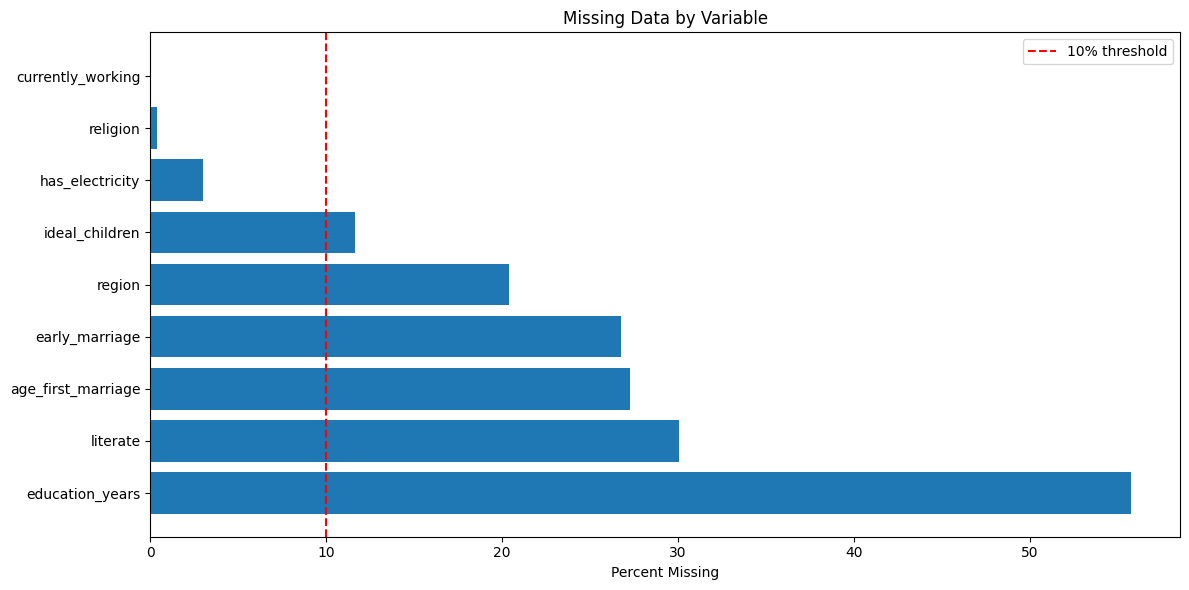

Missing data report saved to reports/figures/


In [9]:
# Cell: Missing Data Report
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize missing data pattern
plt.figure(figsize=(12, 6))
missing_plot = master_df.isna().mean() * 100
missing_plot = missing_plot[missing_plot > 0].sort_values(ascending=False)
bars = plt.barh(range(len(missing_plot)), missing_plot.values)
plt.yticks(range(len(missing_plot)), missing_plot.index)
plt.xlabel('Percent Missing')
plt.title('Missing Data by Variable')
plt.axvline(x=10, color='red', linestyle='--', label='10% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/missing_data_report.png', dpi=300, bbox_inches='tight')
plt.show()

print("Missing data report saved to reports/figures/")

In [10]:
# FIX: Recalculate education years based on education level
print("=== FIXING EDUCATION YEARS ===\n")

# Create a clean copy
master_df_fixed = master_df.copy()

# Map education level to years (Ethiopian context)
def map_education_to_years(level):
    if pd.isna(level):
        return np.nan
    elif level == 'no_education':
        return 0
    elif level == 'primary':
        return 6   # Complete primary (grades 1-6)
    elif level == 'secondary':
        return 10  # Complete secondary (6 primary + 4 secondary)
    elif level == 'higher':
        return 14  # Higher education (10 + 4 years university)
    else:
        return np.nan

# Apply to ALL rows
master_df_fixed['education_years'] = master_df_fixed['education_level'].apply(map_education_to_years)

# Verify the fix
print("Education years after fix:")
print(master_df_fixed.groupby('education_level')['education_years'].mean())

print("\nDistribution of education_years:")
print(master_df_fixed['education_years'].value_counts().sort_index())

# Now recreate the analysis datasets with the fixed data
from src.data_cleaner import create_analysis_ready_datasets

analysis_datasets = create_analysis_ready_datasets(master_df_fixed)

# Verify the fix persisted through imputation
print("\n" + "="*50)
print("VERIFICATION AFTER FIX:")
print("="*50)
print("\nEducation years by education level in MODELING dataset:")
print(analysis_datasets['modeling'].groupby('education_level')['education_years'].mean())

# Save the fixed modeling dataset
modeling_df_fixed = analysis_datasets['modeling']
fixed_path = PROCESSED_DATA_DIR / "ethiopia_early_marriage_modeling_ready_fixed.csv"
modeling_df_fixed.to_csv(fixed_path, index=False)
print(f"\nFixed modeling dataset saved to {fixed_path}")

=== FIXING EDUCATION YEARS ===

Education years after fix:
education_level
higher          14.0
no_education     0.0
primary          6.0
secondary       10.0
Name: education_years, dtype: float64

Distribution of education_years:
education_years
0     34351
6     16567
10     8017
14     2700
Name: count, dtype: int64
Descriptive dataset: 61,635 rows (missing preserved)
Early marriage analysis: 45,135 rows (ever-married only)
Region: Filled 12,564 missing values as 'Unknown'
  Education levels found: ['higher' 'no_education' 'primary' 'secondary']
  Education years: Recalculated for all 61,635 rows based on education level
  Literacy: Imputed 18,528 values, 0 remain
Ideal children: Imputed 7,184 values
Electricity: Imputed 1,843 values
Religion: Imputed 220 values
Working status: Imputed 37 values
Asset count: Recalculated after imputation
Modeling dataset: 61,635 rows (missing imputed)
Complete cases: 37,530 rows (no missing in key vars)

VERIFICATION AFTER FIX:

Education years by e

In [11]:
# Cell: Handle Missing Values for Analysis
from src.data_cleaner import create_analysis_ready_datasets

# Create different versions of the dataset
analysis_datasets = create_analysis_ready_datasets(master_df)

# Verify missing values are handled
print("\n" + "="*50)
print("VERIFICATION: Missing values after handling")
print("="*50)

for name, df in analysis_datasets.items():
    if name == 'descriptive':
        continue  # Skip - we expect missing here
    missing_pct = (df.isna().sum() / len(df)) * 100
    missing_vars = missing_pct[missing_pct > 0]
    if len(missing_vars) > 0:
        print(f"\n{name} - remaining missing:")
        for var, pct in missing_vars.items():
            print(f"  {var}: {pct:.1f}%")
    else:
        print(f"\n{name}: ✓ No missing values remaining")

# Save the modeling dataset for Phase 3 and beyond
modeling_df = analysis_datasets['modeling']
modeling_path = PROCESSED_DATA_DIR / "ethiopia_early_marriage_modeling_ready.csv"
modeling_df.to_csv(modeling_path, index=False)
print(f"\nModeling-ready dataset saved to {modeling_path}")

Descriptive dataset: 61,635 rows (missing preserved)
Early marriage analysis: 45,135 rows (ever-married only)
Region: Filled 12,564 missing values as 'Unknown'
  Education levels found: ['higher' 'no_education' 'primary' 'secondary']
  Education years: Recalculated for all 61,635 rows based on education level
  Literacy: Imputed 18,528 values, 0 remain
Ideal children: Imputed 7,184 values
Electricity: Imputed 1,843 values
Religion: Imputed 220 values
Working status: Imputed 37 values
Asset count: Recalculated after imputation
Modeling dataset: 61,635 rows (missing imputed)
Complete cases: 37,530 rows (no missing in key vars)

VERIFICATION: Missing values after handling

early_marriage_analysis - remaining missing:
  age_first_marriage: 0.7%
  education_years: 67.6%
  literate: 19.8%
  ideal_children: 13.5%
  currently_working: 0.1%
  region: 16.3%
  religion: 0.4%
  has_electricity: 2.6%

modeling - remaining missing:
  age_first_marriage: 27.3%
  early_marriage: 26.8%

complete_cases 

In [12]:
# Cell: Validate imputation quality
print("=== IMPUTATION VALIDATION ===\n")

# Check education_years imputation
print("Education years distribution after imputation:")
print(analysis_datasets['modeling']['education_years'].value_counts().sort_index().head(10))

print("\nEducation years by education level (should match expected):")
print(analysis_datasets['modeling'].groupby('education_level')['education_years'].mean())

# Check region handling
print("\nRegion distribution (including 'Unknown'):")
print(analysis_datasets['modeling']['region'].value_counts())

# Check that never-married women still have NaN for age_first_marriage
never_married = analysis_datasets['modeling'][analysis_datasets['modeling']['ever_married'] == 0]
print(f"\nNever-married women: {len(never_married):,}")
print(f"  age_first_marriage missing: {never_married['age_first_marriage'].isna().sum():,} (should be all)")
print(f"  early_marriage missing: {never_married['early_marriage'].isna().sum():,} (should be all)")

=== IMPUTATION VALIDATION ===

Education years distribution after imputation:
education_years
0     34351
6     16567
10     8017
14     2700
Name: count, dtype: int64

Education years by education level (should match expected):
education_level
higher          14.0
no_education     0.0
primary          6.0
secondary       10.0
Name: education_years, dtype: float64

Region distribution (including 'Unknown'):
region
Unknown              12564
Oromia                8835
SNNPR                 7998
Amhara                7658
Tigray                5973
Benishangul-Gumuz     4223
Afar                  4066
Somali                3818
Dire_Dawa             2735
Addis_Ababa           1824
Gambela               1035
Harari                 906
Name: count, dtype: int64

Never-married women: 16,500
  age_first_marriage missing: 16,500 (should be all)
  early_marriage missing: 16,500 (should be all)


In [13]:
# Cell 8: Save to processed folder
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Save master dataset
output_path = PROCESSED_DATA_DIR / "ethiopia_early_marriage_2000_2016.csv"
master_df.to_csv(output_path, index=False)
print(f"Saved master dataset to {output_path}")

# Also save each year separately
for year, df in final_data.items():
    year_path = PROCESSED_DATA_DIR / f"ethiopia_{year}_cleaned.csv"
    df.to_csv(year_path, index=False)
    print(f"Saved {year} data to {year_path}")

# Save data dictionary
dict_path = PROCESSED_DATA_DIR / "data_dictionary_cleaned.md"
dictionary_content = """
# Cleaned Data Dictionary

## Variable Descriptions

| Variable | Type | Description | Values |
|----------|------|-------------|--------|
| survey_year | int | DHS survey year | 2000, 2005, 2011, 2016 |
| sample_weight | float | DHS survey weight | 0.001 to 5.0 |
| age_first_marriage | float | Age at first marriage (years) | 10-49, NaN if never married |
| early_marriage | int | Married before age 18 | 0=No, 1=Yes, NaN=never married |
| ever_married | int | Ever been married | 0=No, 1=Yes |
| marital_status | str | Current marital status | never_married, married, living_together, widowed, divorced, separated |
| current_age | int | Age in years | 15-49 |
| education_level | str | Highest education level | no_education, primary, secondary, higher |
| education_years | int | Years of education | 0-25 |
| literate | int | Can read | 0=No, 1=Yes |
| children_ever_born | int | Total children ever born | 0-18 |
| children_surviving | int | Children currently alive | 0-18 |
| children_deceased | int | Children who died | 0-10 |
| currently_working | int | Currently employed | 0=No, 1=Yes |
| residence | str | Urban/Rural | urban, rural |
| residence_urban | int | Urban indicator | 0=Rural, 1=Urban |
| region | str | Administrative region | Tigray, Amhara, Oromia, etc. |
| religion | str | Religious affiliation | Orthodox, Muslim, Protestant, etc. |
| wealth_proxy_score | float | PCA wealth score | Continuous |
| wealth_quintile | str | Wealth quintile | Poorest, Poorer, Middle, Richer, Richest |
| has_electricity | int | Household has electricity | 0=No, 1=Yes |
| water_improved | int | Improved water source | 0=No, 1=Yes |
| toilet_improved | int | Improved toilet facility | 0=No, 1=Yes |
| floor_finished | int | Finished floor material | 0=No, 1=Yes |
| asset_count | int | Number of assets owned | 0-4 |

## Data Quality Notes
- Women who never married have NaN for age_first_marriage and early_marriage
- Early marriage defined as age < 18 years
- Wealth proxy created using PCA on household assets
- Survey weights (sample_weight) should be used for population estimates
"""
with open(dict_path, 'w') as f:
    f.write(dictionary_content)
print(f"Saved data dictionary to {dict_path}")

Saved master dataset to C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\data\processed\ethiopia_early_marriage_2000_2016.csv
Saved 2000 data to C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\data\processed\ethiopia_2000_cleaned.csv
Saved 2005 data to C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\data\processed\ethiopia_2005_cleaned.csv
Saved 2011 data to C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\data\processed\ethiopia_2011_cleaned.csv
Saved 2016 data to C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\data\processed\ethiopia_2016_cleaned.csv
Saved data dictionary to C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\data\processed\data_dictionary_cleaned.md
